<a href="https://colab.research.google.com/github/vikrampal12345/Practice_Revision_Machine_learning/blob/main/4_Project1_practice/Practice_date_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [989]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder




In [990]:
df = pd.read_csv("/content/Earth_quick_dataset.csv")
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [991]:
df.shape

(23412, 21)

In [992]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [993]:
df.isnull().mean() * 100

,0
Date,0.000000
Time,0.000000
Latitude,0.000000
Longitude,0.000000
Type,0.000000
Depth,0.000000
Depth Error,80.945669
Depth Seismic Stations,69.686486
Magnitude,0.000000
Magnitude Type,0.012814


In [994]:
var = df.drop(columns=['Horizontal Error', 'Root Mean Square', 'Horizontal Distance', 'Azimuthal Gap', 'Magnitude Seismic Stations', 'Magnitude Error', 'Depth Error', 'Depth Seismic Stations'], axis=1)

In [995]:
var

,Date,Time,Latitude,Longitude,Type,Depth,Magnitude,Magnitude Type,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.2460,145.6160,Earthquake,131.60,6.0,MW,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.8630,127.3520,Earthquake,80.00,5.8,MW,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.5790,-173.9720,Earthquake,20.00,6.2,MW,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.0760,-23.5570,Earthquake,15.00,5.8,MW,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.9380,126.4270,Earthquake,15.00,5.8,MW,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23407,12/28/2016,08:22:12,38.3917,-118.8941,Earthquake,12.30,5.6,ML,NN00570710,NN,NN,NN,Reviewed
23408,12/28/2016,09:13:47,38.3777,-118.8957,Earthquake,8.80,5.5,ML,NN00570744,NN,NN,NN,Reviewed
23409,12/28/2016,12:38:51,36.9179,140.4262,Earthquake,10.00,5.9,MWW,US10007NAF,US,US,US,Reviewed
23410,12/29/2016,22:30:19,-9.0283,118.6639,Earthquake,79.00,6.3,MWW,US10007NL0,US,US,US,Reviewed


In [996]:
var.isnull().mean() * 100

,0
Date,0.000000
Time,0.000000
Latitude,0.000000
Longitude,0.000000
Type,0.000000
Depth,0.000000
Magnitude,0.000000
Magnitude Type,0.012814
ID,0.000000
Source,0.000000


In [997]:
var['Magnitude Type'].value_counts()

,count
Magnitude Type,
MW,7722
MWC,5669
MB,3761
MWB,2458
MWW,1983
MS,1702
ML,77
MWR,26
MD,6


In [998]:
var = var.dropna()
var.isnull().mean() * 100

,0
Date,0.0
Time,0.0
Latitude,0.0
Longitude,0.0
Type,0.0
Depth,0.0
Magnitude,0.0
Magnitude Type,0.0
ID,0.0
Source,0.0


<Axes: xlabel='Type'>

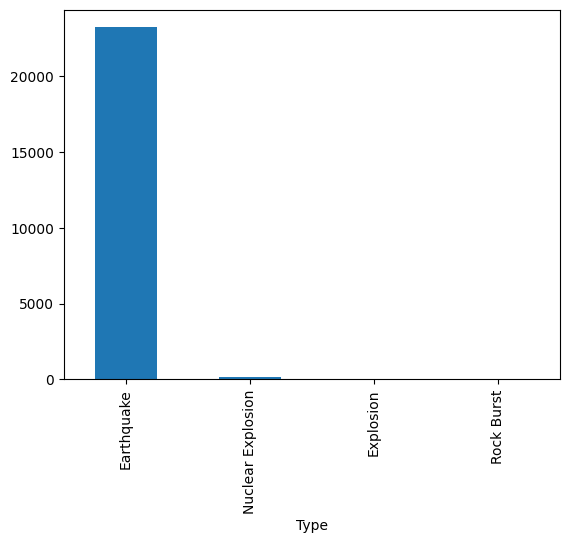

In [999]:
df['Type'].value_counts().plot(kind='bar')

In [1000]:
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


<Axes: ylabel='count'>

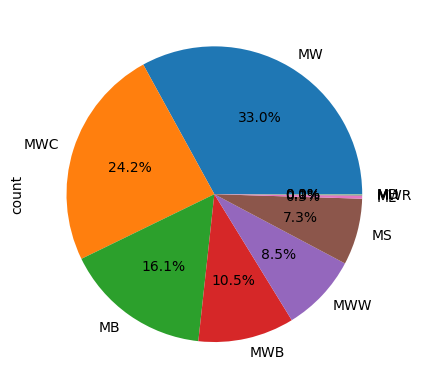

In [1001]:
df['Magnitude Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [1002]:
df['Source'].value_counts()

,count
Source,
US,20630
ISCGEM,2460
ISCGEMSUP,120
CI,61
GCMT,55
NC,51
AK,12
OFFICIAL,8
UW,6


<Axes: xlabel='Location Source'>

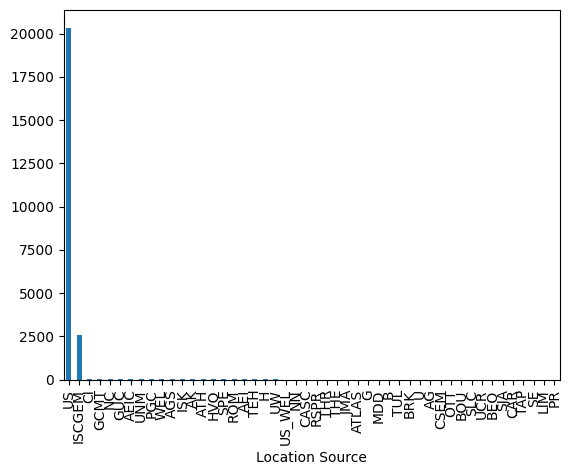

In [1003]:
df['Location Source'].value_counts().plot(kind='bar')

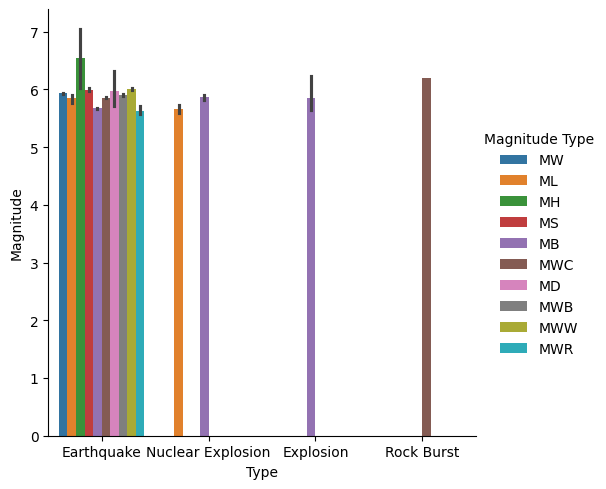

In [1004]:
sns.catplot(data=df, x='Type', y='Magnitude', hue='Magnitude Type', kind='bar')

In [1005]:
df['Status'].value_counts()

,count
Status,
Reviewed,20773
Automatic,2639


In [1006]:
df.isnull().mean() * 100


,0
Date,0.000000
Time,0.000000
Latitude,0.000000
Longitude,0.000000
Type,0.000000
Depth,0.000000
Depth Error,80.945669
Depth Seismic Stations,69.686486
Magnitude,0.000000
Magnitude Type,0.012814


In [1007]:
dff =  df.iloc[:,[0]]
dff.sample(10)

,Date
13876,01/30/1998
4782,04/18/1978
2759,06/24/1973
22435,11/07/2014
17810,04/04/2006
14511,09/18/1999
11610,09/18/1993
12149,10/09/1994
14269,02/12/1999
1762,11/28/1970


In [1008]:
dft = df.iloc[:,[1]]
dft

,Time
0,13:44:18
1,11:29:49
2,18:05:58
3,18:49:43
4,13:32:50
...,...
23407,08:22:12
23408,09:13:47
23409,12:38:51
23410,22:30:19


In [1009]:
dff.isnull().mean() * 100

,0
Date,0.0


In [1010]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    23412 non-null  object
dtypes: object(1)
memory usage: 183.0+ KB


In [1011]:
dff

,Date
0,01/02/1965
1,01/04/1965
2,01/05/1965
3,01/08/1965
4,01/09/1965
...,...
23407,12/28/2016
23408,12/28/2016
23409,12/28/2016
23410,12/29/2016


In [1012]:
# convert the object dtype to datetime64 dtype

dff['Date'] = pd.to_datetime(dff['Date'] , errors='coerce')
# dff['Time'] = pd.to_datetime(dff['Time']).dt.time

/tmp/ipykernel_2818/766121968.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Date'] = pd.to_datetime(dff['Date'] , errors='coerce')


In [1013]:
# dff[dff['Time'].astype(str).str.contains('Z', na=False)]

# `errors` Parameter in `pd.to_datetime()`

## Purpose

The `errors` parameter controls what Pandas should do when it encounters invalid or unparseable date values.

---

## 1. `errors='raise'` (Default)

* Raises an exception if any value cannot be converted to datetime.
* Stops execution immediately.

```python
pd.to_datetime(df['Date'], errors='raise')
```

Example:

```python
Date
01/02/1965
abc
03/15/1970
```

Output:

```python
ValueError: Unknown datetime string format
```

---

## 2. `errors='coerce'`

* Converts invalid dates to `NaT` (Not a Time).
* Does not raise an error.
* Useful for data cleaning and preprocessing.

```python
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
```

Example:

```python
Date
01/02/1965
abc
03/15/1970
```

Output:

```python
1965-01-02
NaT
1970-03-15
```

### Find Invalid Dates

```python
df[df['Date'].isna()]
```

---

## 3. `errors='ignore'`

* Returns the original values without conversion if an error occurs.
* Data type remains unchanged.

```python
pd.to_datetime(df['Date'], errors='ignore')
```

Example:

```python
01/02/1965
abc
03/15/1970
```

Output remains unchanged.

---

## NaN vs NaT

| Data Type | Missing Value |
| --------- | ------------- |
| Numeric   | NaN           |
| Datetime  | NaT           |

---

## Interview Point

`errors='coerce'` is commonly used during data preprocessing because it converts invalid date values to `NaT` instead of raising an error, making it easier to identify and handle problematic records.


In [1014]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    23409 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 183.0 KB


In [1015]:
dff.loc[2095, 'Date']  # exact column

Timestamp('1971-09-24 00:00:00')

In [1016]:
dff

,Date
0,1965-01-02
1,1965-01-04
2,1965-01-05
3,1965-01-08
4,1965-01-09
...,...
23407,2016-12-28
23408,2016-12-28
23409,2016-12-28
23410,2016-12-29


In [1017]:
dff.isnull().mean() * 100

,0
Date,0.012814


In [1018]:
df = dff.dropna()

In [1019]:
df.isnull().mean() * 100

,0
Date,0.0


In [1020]:
df.shape

(23409, 1)

In [1021]:
df['date_year'] = df['Date'].dt.year

/tmp/ipykernel_2818/2948595301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_year'] = df['Date'].dt.year


In [1022]:
df['date_month'] = df['Date'].dt.month

/tmp/ipykernel_2818/730061871.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_month'] = df['Date'].dt.month


In [1023]:
df['date_day'] = df['Date'].dt.day

/tmp/ipykernel_2818/3570945957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_day'] = df['Date'].dt.day


In [1024]:
df['date_month_name'] = df['Date'].dt.month_name()  # month of name

/tmp/ipykernel_2818/3201515891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_month_name'] = df['Date'].dt.month_name()  # month of name


In [1025]:
df['date_week'] = df['Date'].dt.dayofweek

/tmp/ipykernel_2818/1788721625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_week'] = df['Date'].dt.dayofweek


In [1026]:
df['date_day_name'] = df['Date'].dt.day_name()

/tmp/ipykernel_2818/3349789403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_day_name'] = df['Date'].dt.day_name()


In [1027]:
# weekend extract

In [1028]:
df['date_weekend'] = np.where(df['date_day_name'].isin(['Saturday', 'Sunday']),1, 2)

/tmp/ipykernel_2818/1088701948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_weekend'] = np.where(df['date_day_name'].isin(['Saturday', 'Sunday']),1, 2)


In [1029]:
df.loc[:,'date_year_week'] = df['Date'].dt.isocalendar().week

/tmp/ipykernel_2818/4221093152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'date_year_week'] = df['Date'].dt.isocalendar().week


In [1030]:
df['date_quarter'] = df['Date'].dt.quarter

/tmp/ipykernel_2818/3818240469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_quarter'] = df['Date'].dt.quarter


In [1031]:
df['date_semester'] = np.where(df['date_quarter'].isin([1,2]), 1,0)

/tmp/ipykernel_2818/327245936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_semester'] = np.where(df['date_quarter'].isin([1,2]), 1,0)


In [1032]:
# Extract the eclapsed time

import datetime

today = datetime.datetime.today()
today

datetime.datetime(2026, 6, 25, 12, 27, 22, 617107)

In [1033]:
today - df['Date']

,Date
0,22454 days 12:27:22.617107
1,22452 days 12:27:22.617107
2,22451 days 12:27:22.617107
3,22448 days 12:27:22.617107
4,22447 days 12:27:22.617107
...,...
23407,3466 days 12:27:22.617107
23408,3466 days 12:27:22.617107
23409,3466 days 12:27:22.617107
23410,3465 days 12:27:22.617107


In [1034]:
(today - df['Date']).dt.days

,Date
0,22454
1,22452
2,22451
3,22448
4,22447
...,...
23407,3466
23408,3466
23409,3466
23410,3465


In [1035]:
# Month Extract
import pandas as pd
today = pd.Timestamp.today()
df['Date'] = pd.to_datetime(df['Date'])
df['month_extract'] = (today.year - df['Date'].dt.year) * 12 + (today.month - df['Date'].dt.month)

/tmp/ipykernel_2818/1177771407.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
/tmp/ipykernel_2818/1177771407.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_extract'] = (today.year - df['Date'].dt.year) * 12 + (today.month - df['Date'].dt.month)


In [1036]:
df

,Date,date_year,date_month,date_day,date_month_name,date_week,date_day_name,date_weekend,date_year_week,date_quarter,date_semester,month_extract
0,1965-01-02,1965,1,2,January,5,Saturday,1,53,1,1,737
1,1965-01-04,1965,1,4,January,0,Monday,2,1,1,1,737
2,1965-01-05,1965,1,5,January,1,Tuesday,2,1,1,1,737
3,1965-01-08,1965,1,8,January,4,Friday,2,1,1,1,737
4,1965-01-09,1965,1,9,January,5,Saturday,1,1,1,1,737
...,...,...,...,...,...,...,...,...,...,...,...,...
23407,2016-12-28,2016,12,28,December,2,Wednesday,2,52,4,0,114
23408,2016-12-28,2016,12,28,December,2,Wednesday,2,52,4,0,114
23409,2016-12-28,2016,12,28,December,2,Wednesday,2,52,4,0,114
23410,2016-12-29,2016,12,29,December,3,Thursday,2,52,4,0,114


# Working with time


In [1037]:
dft = dft.copy()





In [1038]:
# dft['Time'] = pd.to_datetime(
#     dft['Time'],
#     utc=True,
#     errors='coerce',
#     format='mixed'
# )

In [1039]:
dft['time'] = pd.to_datetime(dft['Time'], utc=True)


/tmp/ipykernel_2818/4221776354.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dft['time'] = pd.to_datetime(dft['Time'], utc=True)


In [1040]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Time    23412 non-null  object             
 1   time    23412 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), object(1)
memory usage: 365.9+ KB


In [1041]:
dft.isnull().mean() * 100

,0
Time,0.0
time,0.0


In [1042]:
dft

,Time,time
0,13:44:18,2026-06-25 13:44:18+00:00
1,11:29:49,2026-06-25 11:29:49+00:00
2,18:05:58,2026-06-25 18:05:58+00:00
3,18:49:43,2026-06-25 18:49:43+00:00
4,13:32:50,2026-06-25 13:32:50+00:00
...,...,...
23407,08:22:12,2026-06-25 08:22:12+00:00
23408,09:13:47,2026-06-25 09:13:47+00:00
23409,12:38:51,2026-06-25 12:38:51+00:00
23410,22:30:19,2026-06-25 22:30:19+00:00


In [1043]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Time    23412 non-null  object             
 1   time    23412 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), object(1)
memory usage: 365.9+ KB


In [1044]:

dft['time1'] = dft['time'].dt.time

In [1045]:

dft['hours'] = dft['time'].dt.hour

In [1046]:

dft['minutes'] = dft['time'].dt.minute

In [1047]:

dft['sec'] = dft['time'].dt.second

In [1048]:
dft

,Time,time,time1,hours,minutes,sec
0,13:44:18,2026-06-25 13:44:18+00:00,13:44:18,13,44,18
1,11:29:49,2026-06-25 11:29:49+00:00,11:29:49,11,29,49
2,18:05:58,2026-06-25 18:05:58+00:00,18:05:58,18,5,58
3,18:49:43,2026-06-25 18:49:43+00:00,18:49:43,18,49,43
4,13:32:50,2026-06-25 13:32:50+00:00,13:32:50,13,32,50
...,...,...,...,...,...,...
23407,08:22:12,2026-06-25 08:22:12+00:00,08:22:12,8,22,12
23408,09:13:47,2026-06-25 09:13:47+00:00,09:13:47,9,13,47
23409,12:38:51,2026-06-25 12:38:51+00:00,12:38:51,12,38,51
23410,22:30:19,2026-06-25 22:30:19+00:00,22:30:19,22,30,19


# Working with data

In [1049]:
var

,Date,Time,Latitude,Longitude,Type,Depth,Magnitude,Magnitude Type,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.2460,145.6160,Earthquake,131.60,6.0,MW,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.8630,127.3520,Earthquake,80.00,5.8,MW,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.5790,-173.9720,Earthquake,20.00,6.2,MW,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.0760,-23.5570,Earthquake,15.00,5.8,MW,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.9380,126.4270,Earthquake,15.00,5.8,MW,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23407,12/28/2016,08:22:12,38.3917,-118.8941,Earthquake,12.30,5.6,ML,NN00570710,NN,NN,NN,Reviewed
23408,12/28/2016,09:13:47,38.3777,-118.8957,Earthquake,8.80,5.5,ML,NN00570744,NN,NN,NN,Reviewed
23409,12/28/2016,12:38:51,36.9179,140.4262,Earthquake,10.00,5.9,MWW,US10007NAF,US,US,US,Reviewed
23410,12/29/2016,22:30:19,-9.0283,118.6639,Earthquake,79.00,6.3,MWW,US10007NL0,US,US,US,Reviewed


<Axes: xlabel='Magnitude', ylabel='Depth'>

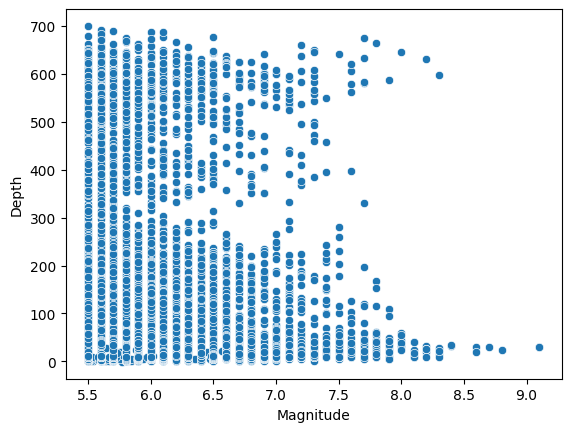

In [1050]:
sns.scatterplot(data=var, x='Magnitude', y = 'Depth')

In [1051]:
mg_count = var['Magnitude'].value_counts()


In [1052]:


bins = [0,5,6,7,float('inf')]

labels = [
    'Moderate',
    'Strong',
    'Very Strong',
    'High'
]

var['Earthquake_Category'] = pd.cut(
    var['Magnitude'],
    bins=bins,
    labels=labels,
    right=False
)

/tmp/ipykernel_2818/188411586.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var['Earthquake_Category'] = pd.cut(


In [1053]:
var.sample(10)

,Date,Time,Latitude,Longitude,Type,Depth,Magnitude,Magnitude Type,ID,Source,Location Source,Magnitude Source,Status,Earthquake_Category
20088,05/19/2010,10:30:10,-54.800,-135.252,Earthquake,10.0,6.0,MWC,USP000HCXV,US,US,GCMT,Reviewed,Very Strong
15592,10/21/2001,19:02:51,-4.855,123.917,Earthquake,33.0,5.7,MWC,USP000ARCM,US,US,HRV,Reviewed,Strong
13170,08/28/1996,16:53:12,-59.994,149.942,Earthquake,10.0,5.9,MWC,USP0007P5V,US,US,HRV,Reviewed,Strong
13473,04/06/1997,04:36:35,39.537,76.998,Earthquake,33.0,6.0,MWC,USP0008018,US,US,HRV,Reviewed,Very Strong
4792,05/01/1978,06:06:57,-19.250,-177.498,Earthquake,578.0,5.5,MB,USP0000UBP,US,US,US,Reviewed,Strong
9359,02/13/1989,12:15:20,4.987,126.915,Earthquake,88.4,5.6,MW,USP0003RVC,US,US,HRV,Reviewed,Strong
11914,05/19/1994,17:52:55,-29.063,-178.376,Earthquake,258.0,5.7,MW,USP0006CTG,US,US,HRV,Reviewed,Strong
10911,05/21/1992,20:40:10,31.025,141.738,Earthquake,13.7,5.9,MW,USP00057UP,US,US,HRV,Reviewed,Strong
2003,07/21/1971,12:03:29,-5.870,154.174,Earthquake,40.0,5.8,MW,ISCGEM782532,ISCGEM,ISCGEM,ISCGEM,Automatic,Strong
12224,12/19/1994,17:41:15,-17.820,-178.631,Earthquake,578.4,5.5,MW,USP0006Q7M,US,US,HRV,Reviewed,Strong


In [1054]:
x = var.iloc[:,[2,3,4,5,7,11,12]]
y = var.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((18727, 7), (4682, 7), (18727,), (4682,))

In [1055]:
X_train

,Latitude,Longitude,Type,Depth,Magnitude Type,Magnitude Source,Status
16096,-3.076,147.943,Earthquake,33.0,MWC,HRV,Reviewed
18317,26.261,-110.537,Earthquake,26.1,MWB,US,Reviewed
7345,-22.986,-66.877,Earthquake,174.3,MW,HRV,Reviewed
4997,47.892,146.569,Earthquake,29.0,MB,US,Reviewed
14273,-2.011,133.483,Earthquake,33.0,MWC,HRV,Reviewed
...,...,...,...,...,...,...,...
1099,9.477,-72.588,Earthquake,175.7,MW,ISCGEM,Automatic
18901,51.522,156.546,Earthquake,134.4,MWB,US,Reviewed
11801,9.891,125.838,Earthquake,34.8,MW,HRV,Reviewed
6637,36.935,141.115,Earthquake,51.7,MB,US,Reviewed


In [1056]:
trf1 = ColumnTransformer([
    ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),[2,4,5,6] )
], remainder='passthrough')

In [1057]:
X_train_new = trf1.fit_transform(X_train)

print(X_train_new.shape)

(18727, 37)


In [1058]:
trf2 = ColumnTransformer([
    ('scaler', MinMaxScaler(), slice(0,37)),
], remainder = 'passthrough')

In [1059]:
trf3 = LogisticRegression()

In [1060]:
le = LabelEncoder()
y_train_new = le.fit_transform(y_train)
y_test_new = le.transform(y_test)


In [1061]:
pipeline = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', trf3)
])

In [1062]:
pipeline.fit(X_train, y_train_new)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 5, 6])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 37, None))])),
                ('trf3', LogisticRegression())])

In [1063]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1064]:
accuracy_score(y_test_new, y_pred)

0.7014096539940197

In [1065]:
from sklearn.model_selection import cross_val_score

cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy',).mean()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

np.float64(0.6992046487325688)

In [1067]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1068]:


import pickle

with open('/content/drive/MyDrive/Earthquake_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("saved")

saved


In [1070]:
test_input = np.array([X_test.iloc[0].values], dtype=object)
test_input

array([[np.float64(-6.742), np.float64(154.889), 'Earthquake',
        np.float64(10.0), 'MWC', 'GCMT', 'Reviewed']], dtype=object)